In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, asdict, field
from typing import List, Tuple
import os

os.makedirs('result', exist_ok=True)
np.random.seed(42)

In [82]:
@dataclass
class DevelopConfig:
    S0: float = 100.0
    T: float = 1.0
    sigma: float = 4.0
    drift: float = 0.0  # 가격 drift (0=무추세, 0.5=약한상승, 1.0=중간상승)
    dt: float = 0.005
    n_steps: int = 200
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: int = 0
    buckets: List[Tuple[float, float]] = field(default_factory=lambda: [
        (0.02, 1.0),
        (0.05, 1.5),
        (0.10, 2.5),
        (float('inf'), 3.5)
    ])

config = DevelopConfig(drift=15)

In [83]:
def generate_mid_price_path(config: DevelopConfig) -> np.ndarray:
    Z = np.random.randn(config.n_steps)
    # drift 항 추가: dS = drift*dt + sigma*sqrt(dt)*Z
    increments = config.drift * config.dt + config.sigma * np.sqrt(config.dt) * Z
    prices = np.zeros(config.n_steps + 1)
    prices[0] = config.S0
    prices[1:] = config.S0 + np.cumsum(increments)
    return prices

def compute_reservation_price(s: float, q: int, t: float, config: DevelopConfig) -> float:
    tau = config.T - t
    return s - q * config.gamma * (config.sigma ** 2) * tau

def compute_optimal_spread(t: float, config: DevelopConfig) -> float:
    tau = config.T - t
    return config.gamma * (config.sigma ** 2) * tau + (2 / config.gamma) * np.log(1 + config.gamma / config.k)

def compute_quotes(s: float, q: int, t: float, config: DevelopConfig) -> Tuple[float, float]:
    r = compute_reservation_price(s, q, t, config)
    spread = compute_optimal_spread(t, config)
    return r - spread / 2, r + spread / 2

def get_fill_multiplier(price_change_pct: float, config: DevelopConfig) -> float:
    abs_change = abs(price_change_pct)
    for threshold, multiplier in config.buckets:
        if abs_change < threshold:
            return multiplier
    return config.buckets[-1][1]

def compute_fill_probability_develop(delta: float, s_current: float, s_next: float, 
                                      is_bid: bool, config: DevelopConfig, is_last_step: bool) -> float:
    if delta <= 0:
        return 1.0
    
    base_intensity = config.A * np.exp(-config.k * delta)
    base_prob = min(base_intensity * config.dt, 1.0)
    
    if is_last_step:
        return base_prob
    
    price_change_pct = (s_next - s_current) / s_current * 100
    multiplier = get_fill_multiplier(price_change_pct, config)
    
    # 양방향 승수 적용
    if price_change_pct > 0:  # 가격 상승
        if not is_bid:  # ask
            return min(base_prob * multiplier, 1.0)
        else:  # bid
            return max(base_prob / multiplier, 0.0)
    elif price_change_pct < 0:  # 가격 하락
        if is_bid:  # bid
            return min(base_prob * multiplier, 1.0)
        else:  # ask
            return max(base_prob / multiplier, 0.0)
    else:
        return base_prob

In [84]:
@dataclass
class SimulationState:
    step: int
    time: float
    mid_price: float
    inventory: int
    cash: float
    reservation_price: float
    spread: float
    bid: float
    ask: float
    bid_fill: bool
    ask_fill: bool
    bid_prob: float = 0.0
    ask_prob: float = 0.0
    price_change_pct: float = 0.0
    multiplier: float = 1.0
    bid_fill_price: float = 0.0
    ask_fill_price: float = 0.0


def run_develop_simulation(config: DevelopConfig, mid_prices: np.ndarray = None) -> List[SimulationState]:
    if mid_prices is None:
        mid_prices = generate_mid_price_path(config)
    
    inventory = config.q0
    cash = 0.0
    history = []
    
    for step in range(config.n_steps):
        t = step * config.dt
        s = mid_prices[step]
        is_last_step = (step == config.n_steps - 1)
        s_next = mid_prices[step + 1] if not is_last_step else s
        
        r = compute_reservation_price(s, inventory, t, config)
        spread = compute_optimal_spread(t, config)
        bid, ask = compute_quotes(s, inventory, t, config)
        
        delta_bid = s - bid
        delta_ask = ask - s
        
        prob_bid = compute_fill_probability_develop(delta_bid, s, s_next, True, config, is_last_step)
        prob_ask = compute_fill_probability_develop(delta_ask, s, s_next, False, config, is_last_step)
        
        bid_fill = np.random.random() < prob_bid
        ask_fill = np.random.random() < prob_ask
        
        # 실제 체결 가격 결정: delta <= 0 이면 mid price로 체결
        bid_fill_price = s if delta_bid <= 0 else bid
        ask_fill_price = s if delta_ask <= 0 else ask
        
        price_change_pct = (s_next - s) / s * 100 if not is_last_step else 0.0
        multiplier = get_fill_multiplier(price_change_pct, config) if not is_last_step else 1.0
        
        state = SimulationState(step, t, s, inventory, cash, r, spread, bid, ask, 
                                bid_fill, ask_fill, prob_bid, prob_ask, price_change_pct, multiplier,
                                bid_fill_price, ask_fill_price)
        history.append(state)
        
        if bid_fill:
            inventory += 1
            cash -= bid_fill_price
        if ask_fill:
            inventory -= 1
            cash += ask_fill_price
    
    final_state = SimulationState(config.n_steps, config.T, mid_prices[-1], inventory, cash,
                                   mid_prices[-1], 0, mid_prices[-1], mid_prices[-1], 
                                   False, False, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0)
    history.append(final_state)
    return history

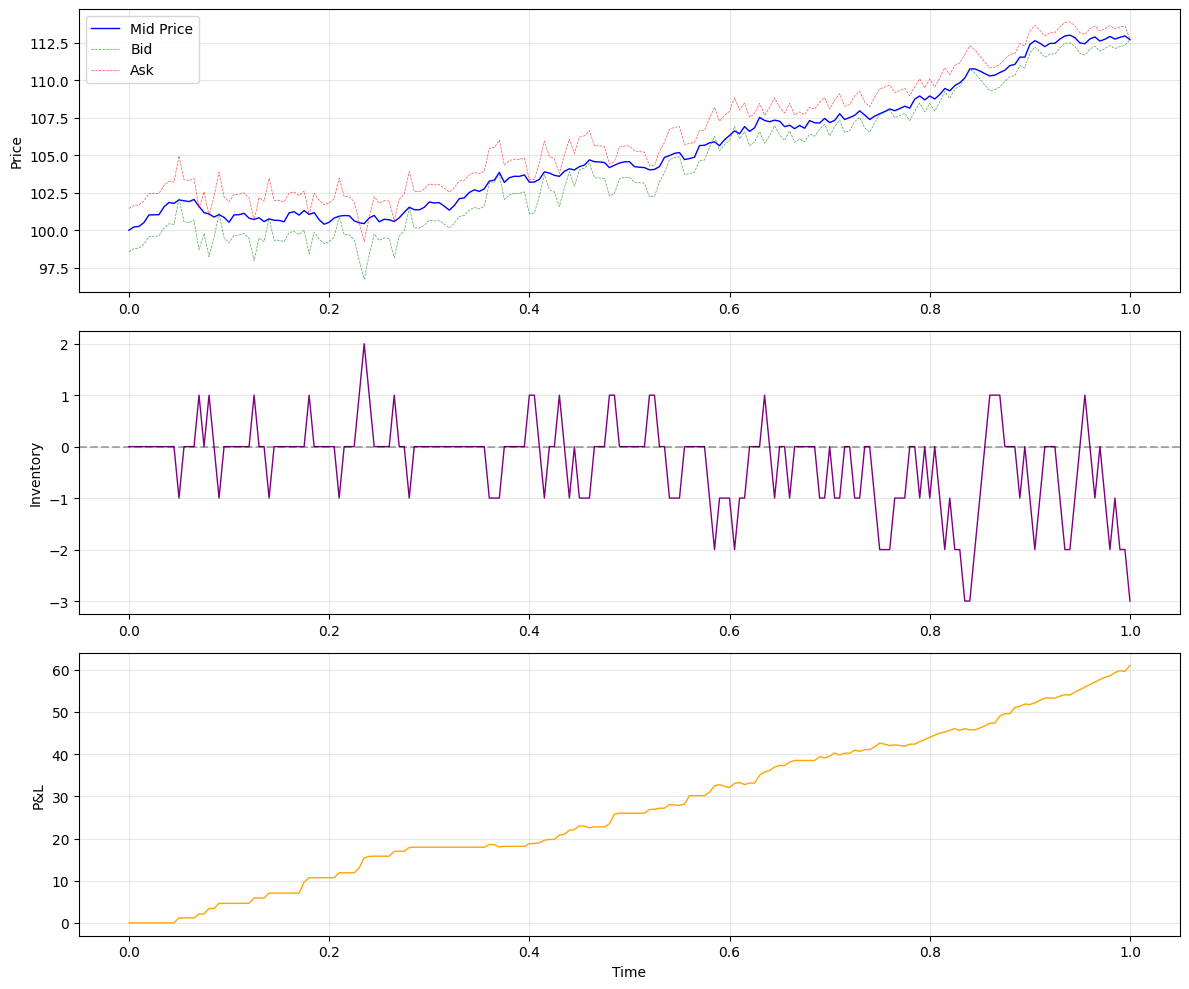

Final Inventory: -3, Cash: 399.10, P&L: 61.02


In [85]:
np.random.seed(42)
mid_prices = generate_mid_price_path(config)
history = run_develop_simulation(config, mid_prices)

times = [s.time for s in history]
mid_price_hist = [s.mid_price for s in history]
bid_hist = [s.bid for s in history]
ask_hist = [s.ask for s in history]
inventory_hist = [s.inventory for s in history]
cash_hist = [s.cash for s in history]
pnl = [cash_hist[i] + inventory_hist[i] * mid_price_hist[i] for i in range(len(history))]

df = pd.DataFrame([asdict(s) for s in history])
df['pnl'] = pnl
df.to_csv('result/develop_simulation_history.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(times, mid_price_hist, 'b-', label='Mid Price', linewidth=1)
axes[0].plot(times, bid_hist, 'g--', label='Bid', alpha=0.7, linewidth=0.5)
axes[0].plot(times, ask_hist, 'r--', label='Ask', alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, inventory_hist, 'purple', linewidth=1)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Inventory')
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, pnl, 'orange', linewidth=1)
axes[2].set_xlabel('Time')
axes[2].set_ylabel('P&L')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/develop_single_simulation.png', dpi=150)
plt.show()

final = history[-1]
print(f"Final Inventory: {final.inventory}, Cash: {final.cash:.2f}, P&L: {pnl[-1]:.2f}")

In [86]:
immediate_fills = sum(1 for s in history[:-1] if s.bid_prob == 1.0 or s.ask_prob == 1.0)
multiplier_applied = sum(1 for s in history[:-1] if s.multiplier > 1.0)

print(f"=== Develop Mode Statistics ===")
print(f"Total steps: {config.n_steps}")
print(f"Immediate fills (delta <= 0): {immediate_fills}")
print(f"Steps with multiplier > 1.0: {multiplier_applied}")
print(f"\nBucket distribution:")
for threshold, mult in config.buckets:
    count = sum(1 for s in history[:-1] if get_fill_multiplier(s.price_change_pct, config) == mult)
    print(f"  multiplier {mult}: {count} steps")

=== Develop Mode Statistics ===
Total steps: 200
Immediate fills (delta <= 0): 43
Steps with multiplier > 1.0: 184

Bucket distribution:
  multiplier 1.0: 16 steps
  multiplier 1.5: 11 steps
  multiplier 2.5: 30 steps
  multiplier 3.5: 143 steps


In [87]:
def run_multiple_develop_simulations(config: DevelopConfig, n_simulations: int = 1000):
    results = {'final_pnl': [], 'final_inventory': [], 'immediate_fills': []}
    
    for _ in range(n_simulations):
        mid_prices = generate_mid_price_path(config)
        history = run_develop_simulation(config, mid_prices)
        final = history[-1]
        results['final_pnl'].append(final.cash + final.inventory * final.mid_price)
        results['final_inventory'].append(final.inventory)
        results['immediate_fills'].append(sum(1 for s in history[:-1] if s.bid_prob == 1.0 or s.ask_prob == 1.0))
    
    return results

print("Running 1000 Develop simulations...")
np.random.seed(42)
develop_results = run_multiple_develop_simulations(config, 1000)

print(f"\n=== Develop Mode Results (1000 simulations) ===")
print(f"P&L: mean = {np.mean(develop_results['final_pnl']):.1f}, std = {np.std(develop_results['final_pnl']):.1f}")
print(f"Final Inventory: mean = {np.mean(develop_results['final_inventory']):.2f}, std = {np.std(develop_results['final_inventory']):.1f}")
print(f"Immediate fills per sim: mean = {np.mean(develop_results['immediate_fills']):.1f}")

Running 1000 Develop simulations...

=== Develop Mode Results (1000 simulations) ===
P&L: mean = 57.0, std = 7.7
Final Inventory: mean = -2.12, std = 2.6
Immediate fills per sim: mean = 41.3


In [88]:
from dataclasses import dataclass as paper_dataclass

@paper_dataclass
class PaperConfig:
    S0: float = 100.0
    T: float = 1.0
    sigma: float = 2.0
    drift: float = 10.0
    dt: float = 0.005
    n_steps: int = 200
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: int = 0

def compute_fill_probability_paper(delta: float, config: PaperConfig) -> float:
    intensity = config.A * np.exp(-config.k * delta)
    return min(intensity * config.dt, 1.0)

def run_paper_simulation(config: PaperConfig, mid_prices: np.ndarray) -> List[SimulationState]:
    inventory = config.q0
    cash = 0.0
    history = []
    
    for step in range(config.n_steps):
        t = step * config.dt
        s = mid_prices[step]
        
        r = compute_reservation_price(s, inventory, t, config)
        spread = compute_optimal_spread(t, config)
        bid, ask = compute_quotes(s, inventory, t, config)
        
        delta_bid = s - bid
        delta_ask = ask - s
        
        prob_bid = compute_fill_probability_paper(delta_bid, config)
        prob_ask = compute_fill_probability_paper(delta_ask, config)
        
        bid_fill = np.random.random() < prob_bid
        ask_fill = np.random.random() < prob_ask
        
        state = SimulationState(step, t, s, inventory, cash, r, spread, bid, ask, 
                                bid_fill, ask_fill, prob_bid, prob_ask, 0.0, 1.0, bid, ask)
        history.append(state)
        
        if bid_fill:
            inventory += 1
            cash -= bid
        if ask_fill:
            inventory -= 1
            cash += ask
    
    final_state = SimulationState(config.n_steps, config.T, mid_prices[-1], inventory, cash,
                                   mid_prices[-1], 0, mid_prices[-1], mid_prices[-1], 
                                   False, False, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0)
    history.append(final_state)
    return history

def run_multiple_paper_simulations(config: PaperConfig, n_simulations: int = 1000):
    results = {'final_pnl': [], 'final_inventory': []}
    
    for _ in range(n_simulations):
        mid_prices = generate_mid_price_path(config)
        history = run_paper_simulation(config, mid_prices)
        final = history[-1]
        results['final_pnl'].append(final.cash + final.inventory * final.mid_price)
        results['final_inventory'].append(final.inventory)
    
    return results

In [89]:
print("Comparing Paper vs Develop mode...")
paper_config = PaperConfig()

np.random.seed(42)
paper_results = run_multiple_paper_simulations(paper_config, 1000)
np.random.seed(42)
develop_results = run_multiple_develop_simulations(config, 1000)

print(f"\n{'Mode':<12} {'P&L Mean':<12} {'P&L Std':<12} {'Inv Mean':<12} {'Inv Std':<12}")
print("-" * 60)
print(f"{'Paper':<12} {np.mean(paper_results['final_pnl']):<12.1f} {np.std(paper_results['final_pnl']):<12.1f} {np.mean(paper_results['final_inventory']):<12.2f} {np.std(paper_results['final_inventory']):<12.1f}")
print(f"{'Develop':<12} {np.mean(develop_results['final_pnl']):<12.1f} {np.std(develop_results['final_pnl']):<12.1f} {np.mean(develop_results['final_inventory']):<12.2f} {np.std(develop_results['final_inventory']):<12.1f}")

Comparing Paper vs Develop mode...

Mode         P&L Mean     P&L Std      Inv Mean     Inv Std     
------------------------------------------------------------
Paper        64.7         7.7          -0.06        3.1         
Develop      57.0         7.7          -2.12        2.6         


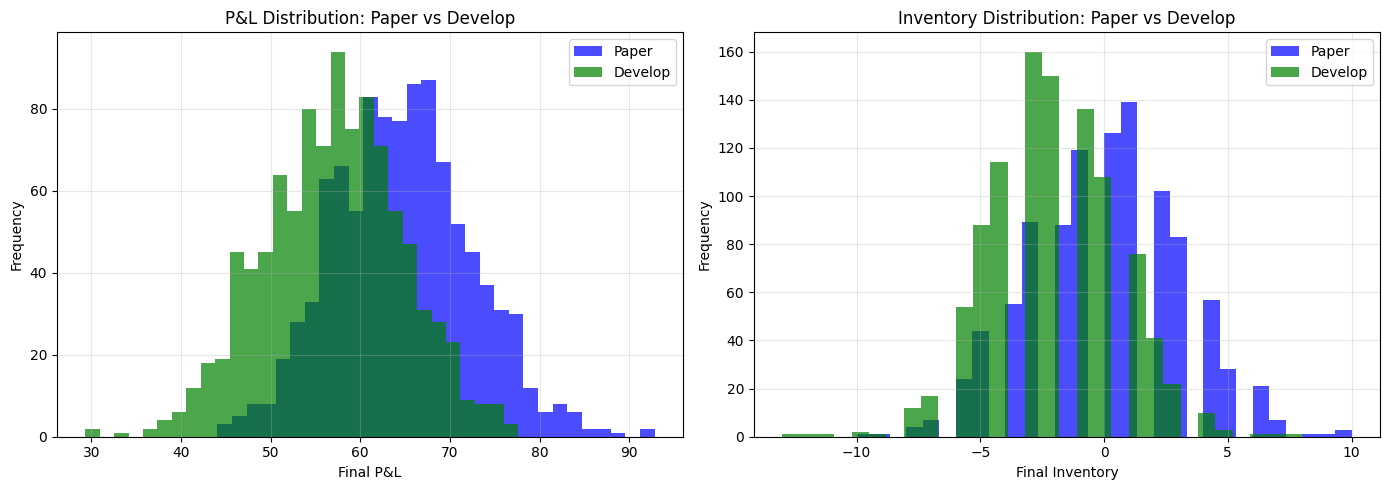

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(paper_results['final_pnl'], bins=30, alpha=0.7, label='Paper', color='blue')
axes[0].hist(develop_results['final_pnl'], bins=30, alpha=0.7, label='Develop', color='green')
axes[0].set_xlabel('Final P&L')
axes[0].set_ylabel('Frequency')
axes[0].set_title('P&L Distribution: Paper vs Develop')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(paper_results['final_inventory'], bins=30, alpha=0.7, label='Paper', color='blue')
axes[1].hist(develop_results['final_inventory'], bins=30, alpha=0.7, label='Develop', color='green')
axes[1].set_xlabel('Final Inventory')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Inventory Distribution: Paper vs Develop')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/paper_vs_develop_comparison.png', dpi=150)
plt.show()